# EMFN v3 구조와 어블레이션

> 2026-10-05 안내: 이 노트북의 그림·표는 오류 수정 후의 기존 실행을 다룹니다. 최신 다중 시드 결과와 현재 본문/부록 배치는 02 노트북 및 reports/baseline_benchmarks_and_future_plan.md를 참고하십시오.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
from IPython.display import display, Image
ROOT = Path.cwd()
if not (ROOT/'configs/base_config.yaml').exists(): ROOT = ROOT.parent
manifest = json.loads((ROOT/'reports/corrected_run_manifest.json').read_text(encoding='utf-8'))
run = ROOT/'models/runs'/manifest['run_id']
print(manifest['run_id'], '|', manifest['test_role'])

corrected_v3_20261004T005217+0900 | development_benchmark_previously_consulted


공유 TCN이 발전량과 기상 채널을 함께 인코딩하고, magnitude/zero adapter로 나뉩니다. HF/AR 경로는 발전량의 최근값과 변동을 직접 전달합니다. 선택적 기상 게이트는 풍속·기압·기온·영발전 빈도에서 만든 특징을 분류 분기에 추가하는 MLP입니다.

`sigmoid(z_zero)`는 이름과 달리 **p = P(Y>0|X)**입니다. alpha/beta는 softplus로 양수를 보장합니다.

- P(Y=0|X) = 1-p
- Y/21 | Y>0,X ~ Beta(alpha,beta)
- E[Y|X] = 21 × p × alpha/(alpha+beta)

따라서 분포의 지지집합은 [0,21]이고 0에 질량이 있습니다. 평균 예측은 확률이 중간이면 대체로 양수이므로 영발전 라벨과 일치하는 0을 항상 출력하지 않습니다. 분류 확률과 중앙값을 별도로 봐야 합니다. 상한 21에 별도 점질량은 없습니다.

이는 유계와 영발전 질량을 반영한 통계 모델입니다. 기계적 시동/정지 법칙, 파워 커브 또는 기상 변수의 인과 효과를 내장·식별하지 않습니다. TCN의 causal은 시간 처리 방향을 뜻합니다. GroupNorm은 입력 윈도우 내 시간 위치를 함께 정규화하므로 각 토큰 단위의 엄격한 prefix causal 표현이라는 주장도 하지 않습니다. 예측 발행 시점 이후 정보가 입력되지 않는지로 누수를 검증합니다.

기존 회귀 변형은 분기와 gate, 손실도 바뀝니다. 이 표는 순수 출력 헤드 비교가 아닙니다.

,model,horizon,count,mae,rmse,zero_auprc,bound_violation_pct
0,EMFN (Proposed),+1h,8736,0.8018,1.2758,0.758931,0.0000
1,EMFN (Endogenous Only),+1h,8736,0.8313,1.3308,0.715196,0.0000
2,EMFN (w/o HF Skips),+1h,8736,0.8206,1.3008,0.748502,0.0000
3,EMFN (w/o Selective Gate),+1h,8736,0.8164,1.3050,0.652300,0.0000
4,EMFN (Deterministic Regression),+1h,8736,0.7789,1.2564,NaN,5.5403
5,EMFN (Proposed),+3h,8734,1.5816,2.3828,0.559593,0.0000
6,EMFN (Endogenous Only),+3h,8734,1.6395,2.4904,0.505789,0.0000
7,EMFN (w/o HF Skips),+3h,8734,1.5264,2.3435,0.586304,0.0000
8,EMFN (w/o Selective Gate),+3h,8734,1.4986,2.3203,0.503214,0.0000
9,EMFN (Deterministic Regression),+3h,8734,1.4805,2.2757,NaN,1.4999


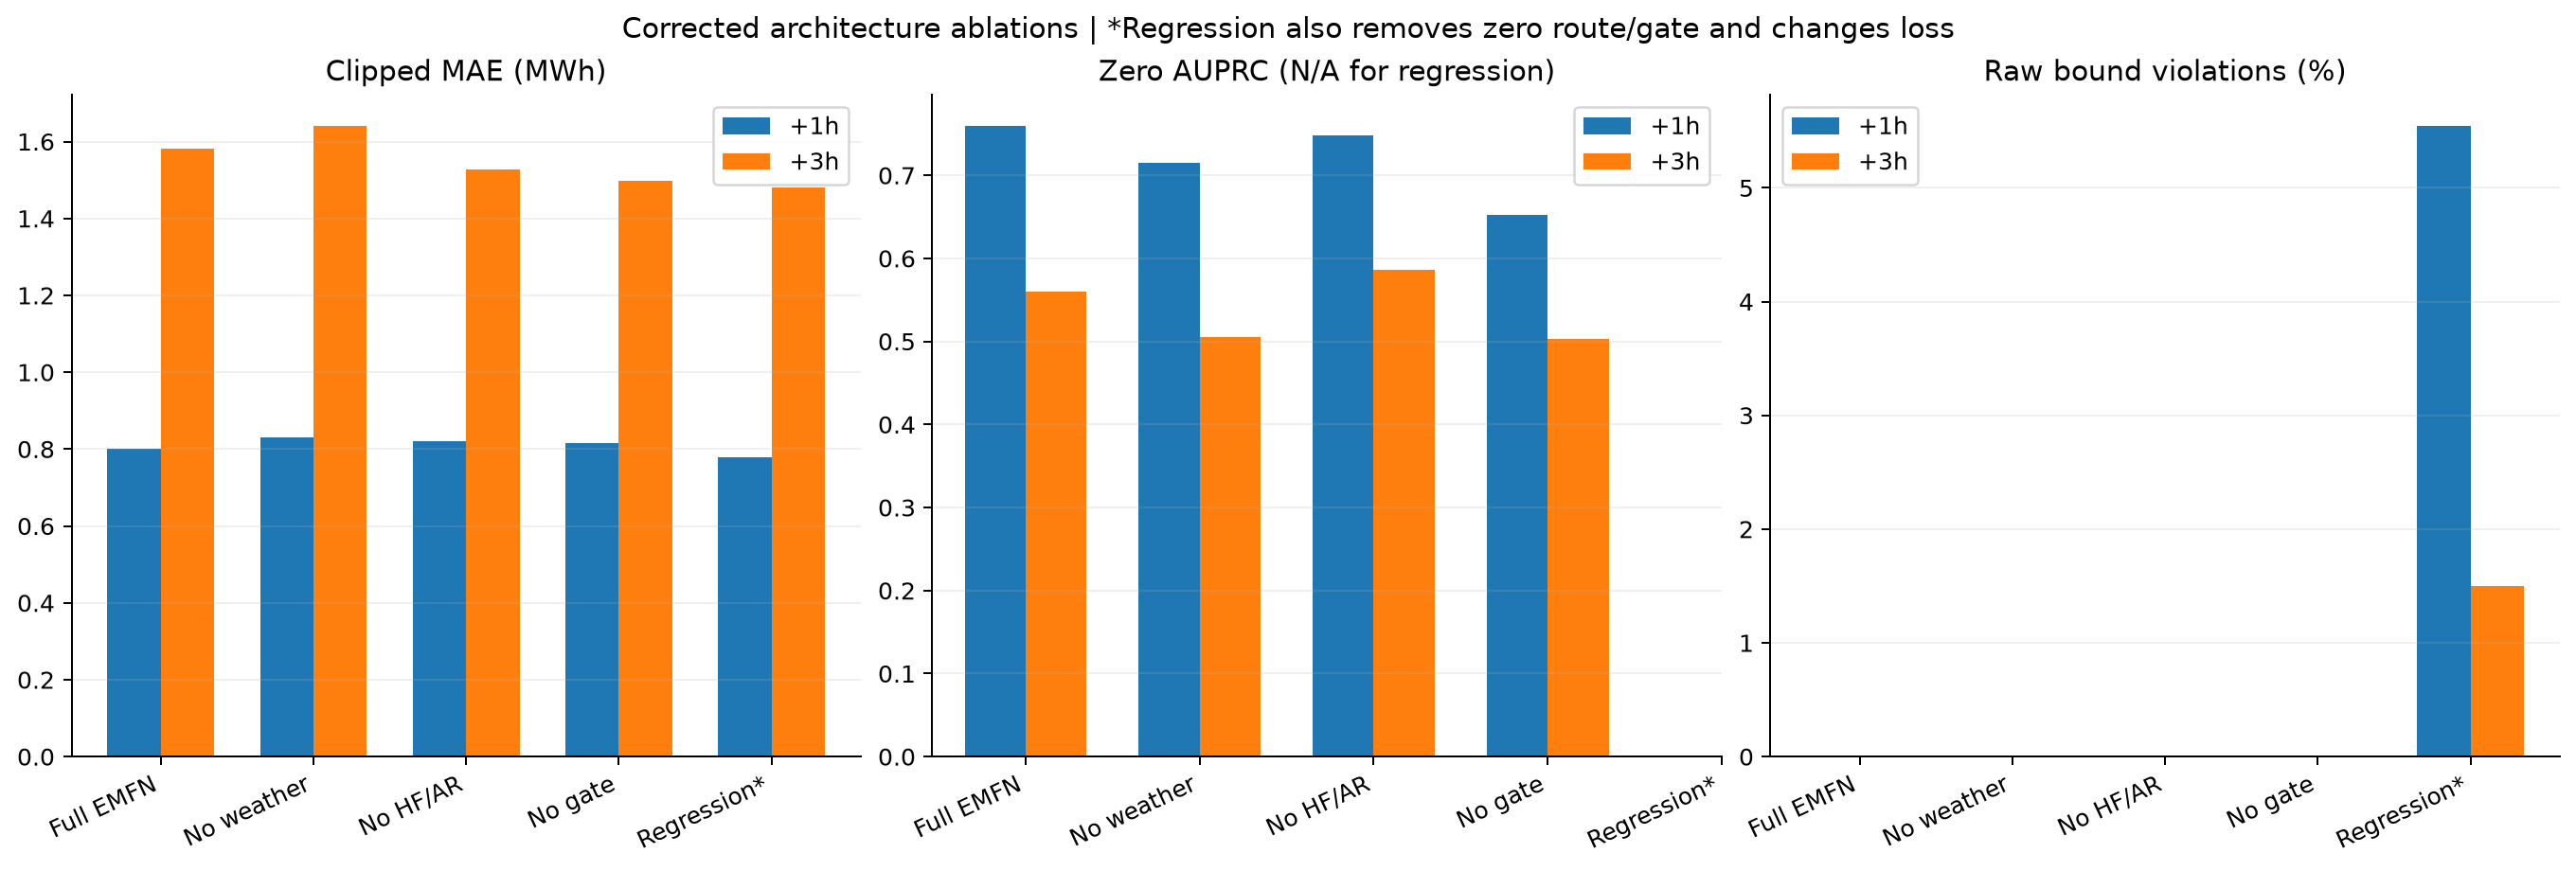

In [2]:
a=pd.read_csv(ROOT/'reports/tables/emfn_comprehensive_ablation_matrix.csv')
display(a[['model','horizon','count','mae','rmse','zero_auprc','bound_violation_pct']])
display(Image(filename=str(ROOT/'reports/figures/emfn_ablation_comparison.png')))

In [3]:
f=pd.read_parquet(run/'emfn__proposed_1h_common.parquet')
expected=21*f.p_pos*f.alpha/(f.alpha+f.beta)
np.testing.assert_allclose(expected,f.y_pred_raw,rtol=1e-5,atol=1e-5)
print('혼합 평균 공식 일치; 관측 영발전 비율:', f.y_true.eq(0).mean())

혼합 평균 공식 일치; 관측 영발전 비율: 0.16323260073260074
